# Classificazione dei prezzi delle case
### Progetto Finale – Introduzione alla Data Science AA 2025/2026

In questo notebook viene sviluppata una pipeline completa di data science applicata a un dataset di prezzi delle case in California (1999). L'obiettivo è prevedere la classe di prezzo di una casa — suddivisa in 5 fasce da $0 a oltre $300.000 — a partire da informazioni geografiche, demografiche e strutturali delle aree di vendita.
Vengono implementati e confrontati quattro algoritmi di classificazione: minimizzazione del rischio empirico con loss quadratica e logistica, k-NN, alberi decisionali e Random Forest. La selezione del modello è condotta tramite cross-validation stratificata per garantire una buona capacità di generalizzazione sul test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1. Caricamento dati

In [2]:
# Apro il file csv sfruttando la libreria pandas
houses_data = pd.read_csv("houses_data.csv")

# Visualizzo le prime 5 righe
houses_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,distance_to_coast,distance_to_la,distance_to_sandiego,distance_to_sanjose,distance_to_sanfrancisco,median_house_value
0,-121.48,38.58,42.0,1823.0,566.0,761.0,503.0,1.2450,56605.775179,580889.416012,759695.004208,143043.151608,122257.998578,1
1,-118.16,33.96,24.0,1635.0,507.0,2480.0,481.0,2.4432,23275.681574,12833.107273,166591.203013,504538.443854,572564.270481,2
2,-116.41,33.74,17.0,4289.0,893.0,958.0,440.0,2.4659,109783.652563,172765.858404,133611.248886,636951.380308,704278.553944,2
3,-118.28,33.92,39.0,1274.0,282.0,975.0,277.0,1.5114,12482.064427,15080.299933,169527.675887,500778.155643,568764.984549,0
4,-118.20,33.96,41.0,1512.0,400.0,1690.0,367.0,3.0550,21094.938610,11018.189002,168689.069801,502131.598805,570150.638590,2


In [3]:
# Comando pandas per controllare che il caricamento sia avvenuto correttamente
print("Shape del dataset:", houses_data.shape)

# Comando pandas per controllare la struttura del dataset, i tipi di dato e la presenza di valori nulli
houses_data.info()

Shape del dataset: (10320, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10320 entries, 0 to 10319
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 10320 non-null  float64
 1   latitude                  10320 non-null  float64
 2   housing_median_age        10320 non-null  float64
 3   total_rooms               10320 non-null  float64
 4   total_bedrooms            10222 non-null  float64
 5   population                10320 non-null  float64
 6   households                10320 non-null  float64
 7   median_income             10320 non-null  float64
 8   distance_to_coast         10320 non-null  float64
 9   distance_to_la            10320 non-null  float64
 10  distance_to_sandiego      10320 non-null  float64
 11  distance_to_sanjose       10320 non-null  float64
 12  distance_to_sanfrancisco  10320 non-null  float64
 13  median_house_value        1032

> _"Quali variabili sono categoriali e quali numeriche?"_

Tutte le variabili sono numeriche, quindi non è necessario alcun encoding. 
Il target median_house_value è però da considerare categoriale ordinale (valori 0–4 che rappresentano fasce di prezzo), motivo per cui il problema viene trattato come classificazione e non regressione.

In [4]:
# Comando pandas che mi genera le statistiche descrittive principali per le colonne numeriche, quindi per capire la distribuzione dei dati 
houses_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,distance_to_coast,distance_to_la,distance_to_sandiego,distance_to_sanjose,distance_to_sanfrancisco,median_house_value
count,10320.000000,10320.000000,10320.000000,10320.000000,10222.000000,10320.000000,10320.000000,10320.000000,10320.000000,1.032000e+04,1.032000e+04,10320.000000,10320.000000,10320.000000
mean,-119.574194,35.631556,28.659109,2649.005233,541.292115,1428.653876,502.031686,3.870005,39986.334263,2.694664e+05,3.982357e+05,349115.721531,386382.436629,2.006202
std,2.008333,2.137086,12.647918,2234.288240,434.323321,1161.103443,392.034757,1.882240,48666.189096,2.482746e+05,2.899353e+05,217399.018702,250646.207798,1.405746
min,-124.350000,32.560000,1.000000,6.000000,1.000000,3.000000,1.000000,0.499900,120.676447,4.205891e+02,4.849180e+02,569.448118,456.141313,0.000000
25%,-121.810000,33.930000,18.000000,1444.750000,295.000000,783.000000,279.000000,2.586500,8957.536866,3.195457e+04,1.594064e+05,111852.242379,116229.091976,1.000000
50%,-118.480000,34.250000,29.000000,2120.000000,435.000000,1167.000000,410.000000,3.550350,20373.551257,1.731238e+05,2.136897e+05,460412.398510,527470.345092,2.000000
75%,-118.000000,37.720000,37.000000,3150.000000,649.000000,1722.000000,606.000000,4.723900,48696.800918,5.276142e+05,7.062628e+05,517220.075858,584842.116382,3.000000
max,-114.310000,41.950000,52.000000,32054.000000,5290.000000,35682.000000,5050.000000,15.000100,333804.686371,1.018260e+06,1.196919e+06,836762.678210,903627.663298,4.000000


In [5]:
# Separo la variabile target dalle features
X = houses_data.drop(columns=["median_house_value"])    # Tutte le colonne tranne median_house_value
y = houses_data["median_house_value"]                   # La colonna median_house_value

print("Shape di X:", X.shape)
print("Shape di y:", y.shape)


Shape di X: (10320, 13)
Shape di y: (10320,)


## 2. Visualizzazione dei dati

### 2.1 Dati mancanti

In [6]:
# Comando pandas e numpy per visualizzare quanti valori mancanti ci sono in ogni colonna 
houses_data.isnull().sum()

longitude                    0
latitude                     0
housing_median_age           0
total_rooms                  0
total_bedrooms              98
population                   0
households                   0
median_income                0
distance_to_coast            0
distance_to_la               0
distance_to_sandiego         0
distance_to_sanjose          0
distance_to_sanfrancisco     0
median_house_value           0
dtype: int64

> _"Ci sono valori mancanti? Quanti e su quali variabili? Come li puoi gestire?"_

I valori mancanti sono presenti solo sulla variabile total_bedrooms. Per gestirli si sceglie di applicare la mediana della colonna, preferita alla media perché più robusta alla presenza di outlier nei dati.

### 2.2 Classe bilanciate

In [7]:
# Comando pandas per verificare che le classi siano blianciate
y.value_counts()

median_house_value
3    2112
1    2088
2    2072
4    2034
0    2014
Name: count, dtype: int64

<Axes: xlabel='median_house_value'>

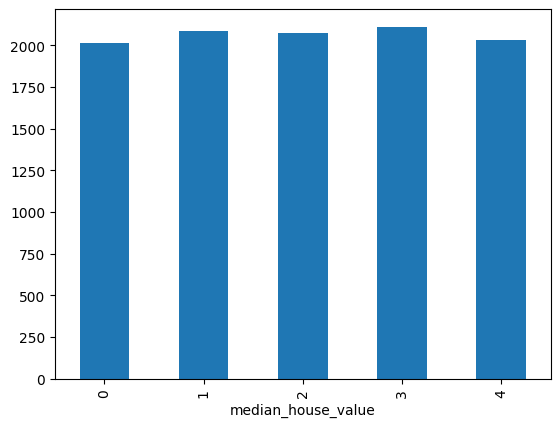

In [8]:
# Plotto un istogramma per mostrare il bilanciamento delle classi
y.value_counts().sort_index().plot(kind='bar')

Le 5 classi risultano sostanzialmente bilanciate. Non è quindi necessario adottare tecniche specifiche per gestire lo sbilanciamento delle classi.

### 2.3 Correlazione
Ipotesi: Mi aspetto che median_income sia la variabile più correlata al prezzo delle case, poiché il reddito di un'area è tipicamente un forte indicatore del valore immobiliare. Mi aspetto inoltre che total_rooms, total_bedrooms, households e population siano molto correlate tra loro, in quanto descrivono tutte la densità abitativa di un'area.

In [9]:
# Comando pandas per trovare la matrice di correlazione
houses_data.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,distance_to_coast,distance_to_la,distance_to_sandiego,distance_to_sanjose,distance_to_sanfrancisco,median_house_value
longitude,1.000000,-0.926031,-0.114574,0.056240,0.077455,0.108117,0.062041,-0.015004,0.012408,-0.893846,-0.959356,0.923300,0.954371,-0.026161
latitude,-0.926031,1.000000,0.021241,-0.048272,-0.075301,-0.116021,-0.077754,-0.080752,0.297101,0.941731,0.991669,-0.855404,-0.897521,-0.183050
housing_median_age,-0.114574,0.021241,1.000000,-0.366092,-0.328487,-0.303447,-0.313226,-0.115003,-0.223949,-0.020962,0.045640,-0.093149,-0.105845,0.077167
total_rooms,0.056240,-0.048272,-0.366092,1.000000,0.933320,0.853595,0.919446,0.192457,-0.000882,-0.029617,-0.050446,0.042343,0.043379,0.145598
total_bedrooms,0.077455,-0.075301,-0.328487,0.933320,1.000000,0.873360,0.978142,-0.006420,-0.021800,-0.062033,-0.076002,0.066488,0.067203,0.075369
population,0.108117,-0.116021,-0.303447,0.853595,0.873360,1.000000,0.903577,0.007413,-0.038781,-0.115478,-0.116675,0.086753,0.096053,0.013713
households,0.062041,-0.077754,-0.313226,0.919446,0.978142,0.903577,1.000000,0.014753,-0.061604,-0.066277,-0.075252,0.053360,0.055500,0.095207
median_income,-0.015004,-0.080752,-0.115003,0.192457,-0.006420,0.007413,0.014753,1.000000,-0.241643,-0.065954,-0.055792,-0.034445,-0.020542,0.625336
distance_to_coast,0.012408,0.297101,-0.223949,-0.000882,-0.021800,-0.038781,-0.061604,-0.241643,1.000000,0.189661,0.207754,-0.073872,-0.064099,-0.529245
distance_to_la,-0.893846,0.941731,-0.020962,-0.029617,-0.062033,-0.115478,-0.066277,-0.065954,0.189661,1.000000,0.951367,-0.794312,-0.848815,-0.166055


<Axes: >

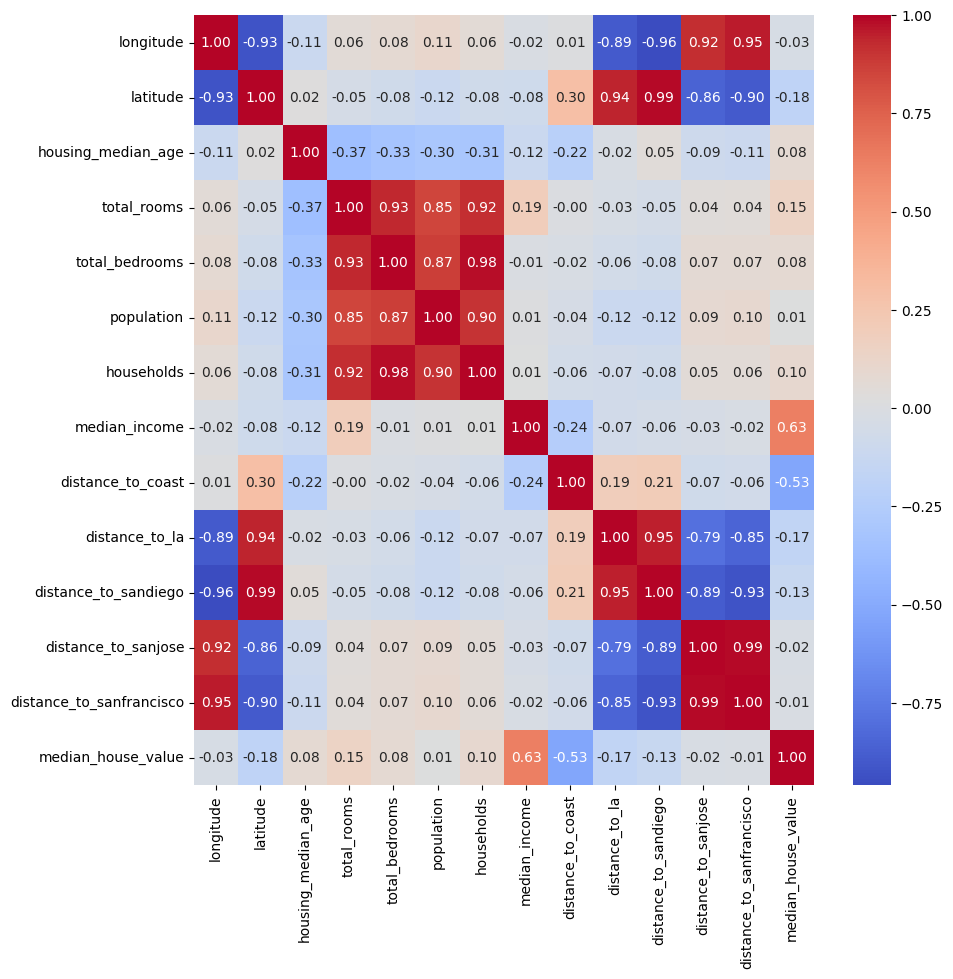

In [10]:
# Comando di seaborn per visualizzare la matrice di correlazione tramite una heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(houses_data.corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')

Verifica delle ipotesi:   
Come ipotizzato, median_income risulta la variabile più correlata al target (0.63), confermando che il reddito mediano di un'area è il principale predittore del valore delle case. Anche distance_to_coast mostra una correlazione significativa ma negativa (-0.53): le case vicine alla costa tendono ad avere prezzi più alti.
Le variabili total_rooms, total_bedrooms, households e population risultano fortemente correlate tra loro (valori tra 0.85 e 0.98), descrivendo tutte la stessa dimensione di densità abitativa dell'area. Infine, longitude e latitude sono altamente correlate con le distanze dalle città, coerentemente con la loro natura geografica.

## 3. Codifica della variabile target